# Agent Orchestration: Hierarchical Orchestration (Teams of Teams)

In the final notebook of this module, we explore how to scale orchestration to a massive level. When you have dozens of specialized agents, a single supervisor becomes a bottleneck. We solve this using **Hierarchical Orchestration**.

## 1. What is Hierarchical Orchestration?
Think of this as a **Corporate Hierarchy**:
- **Executive (Top Supervisor)**: Understands the high-level goal and delegates to Department Managers.
- **Managers (Team Leads)**: Manage a small, specialized graph of agents for a specific domain (e.g., a "Coding Team" or a "Research Team").
- **Workers**: The individual agents performing the tasks.

---

## 2. Environment Setup
We will simulate a small hierarchy using Gemini 2.5 Flash.

In [7]:
import os
from typing import Annotated, TypedDict, List, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

print("Enterprise Hierarchy Setup Ready!")

Enterprise Hierarchy Setup Ready!


## 3. The Shared State
In hierarchical systems, teams often have their own local state, but they also report back to a global state.

In [2]:
class GlobalState(TypedDict):
    messages: Annotated[List[BaseMessage], lambda a, b: a + b]
    next_team: str

## 4. Defining the Team Leaders (Sub-Graphs)
In a real system, these would be separate `StateGraph` objects. Here, we simulate the "Team Response" for clarity.

In [3]:
def writing_team_node(state: GlobalState):
    print("--- Writing Team is working... ---")
    system_msg = SystemMessage(content="You represent the Writing Team Leader. Summarize the user requirements into a polished document fragment.")
    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [AIMessage(content=response.content, name="WritingTeam")]}

def technical_team_node(state: GlobalState):
    print("--- Technical Team is working... ---")
    system_msg = SystemMessage(content="You represent the Technical Team Leader. Provide technical specifications or code structure based on the request.")
    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [AIMessage(content=response.content, name="TechTeam")]}

## 5. The Executive Router


In [4]:
class ExecutiveDecision(BaseModel):
    """Delegate the project to the right department."""
    department: Literal["Writing", "Technical", "FINISH"] = Field(
        ..., 
        description="Which department should handle this request?"
    )

executive_llm = llm.with_structured_output(ExecutiveDecision)

def executive_node(state: GlobalState):
    system_msg = SystemMessage(content="""You are the Chief Operating Officer. 
                               Analyze the request and delegate to Writing or Technical teams. 
                               Once both have contributed or the task is done, choose FINISH.""")
    decision = executive_llm.invoke([system_msg] + state["messages"])
    return {"next_team": decision.department}

## 6. Building & Visualizing the Hierarchical Graph
The Chief Executive controls the departments. This high-level view shows the orchestration of entire teams.

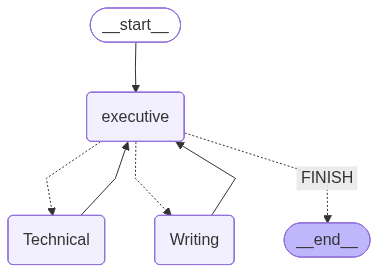

In [5]:
builder = StateGraph(GlobalState)

builder.add_node("executive", executive_node)
builder.add_node("Writing", writing_team_node)
builder.add_node("Technical", technical_team_node)

builder.add_edge(START, "executive")
builder.add_edge("Writing", "executive")
builder.add_edge("Technical", "executive")

builder.add_conditional_edges(
    "executive",
    lambda x: x["next_team"],
    {
        "Writing": "Writing",
        "Technical": "Technical",
        "FINISH": END
    }
)

app = builder.compile()

# Visualize
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Visualization failed.")

## 7. Execution: The Multi-Department Request
Let's see the CEO delegate to multiple departments.

In [6]:
query = "We need to build a new authentication system. Write a technical spec and an executive summary for the board."
for chunk in app.stream({"messages": [HumanMessage(content=query)]}, stream_mode="values"):
    if chunk["messages"]:
        last_msg = chunk["messages"][-1]
        if hasattr(last_msg, "name") and last_msg.name:
            print(f"\n--- Department: {last_msg.name} ---")
            print(last_msg.content)

--- Technical Team is working... ---

--- Department: TechTeam ---
Okay, this is a critical project! I'll provide both an Executive Summary for the Board and a detailed Technical Specification.

---

## Executive Summary for the Board: New Authentication System

**To:** The Board of Directors
**From:** [Your Name/Technical Team Leader]
**Date:** October 26, 2023
**Subject:** Proposal for a New, Modern Authentication System

**1. Purpose:**
This document proposes the development and implementation of a new, state-of-the-art authentication system. Our current authentication infrastructure, while functional, presents growing challenges in terms of security posture, user experience, scalability, and compliance with evolving data protection regulations. A modern system is essential to protect our users, our data, and our reputation, while also enabling future product innovation.

**2. The Challenge:**
Our existing authentication system was designed for a different era. It lacks native suppo

## 8. Summary & Enterprise Pro-Tips
1. **Information Bottlenecks**: In a hierarchy, individual workers don't see the full history—only what their manager sends them. This reduces "Large Context window" costs and improves privacy.
2. **Specialized Repositories**: In production, each "Team" might have its own dedicated Vector Database and Tool set.
3. **Human Oversight**: In a business, you might add a "Human Approval" edge before the Executive can mark the task as `FINISH`.

Congratulations! You have mastered from the foundations of prompting to the complexities of Hierarchical Multi-Agent Orchestration. 

---